Må ha minst to dataset

## Import datasettene fra NVDB (ikke lokale GeoJSON-filer)

Her henter vi *to* datasett direkte fra NVDB API Les (V4-host):

- **Vegbredde** (objekttype `838`)

- **Høydebegrensning** (objekttype `591`)

Vi begrenser spørringen til en `kartutsnitt`-bbox (WGS84), og laster resultatet som `GeoDataFrame` for videre GIS-analyse.

In [104]:
from __future__ import annotations

from typing import Any
import time
import requests
import certifi

import pandas as pd
import geopandas as gpd

from shapely import wkt
from shapely.ops import transform

# Samme API-mønster som webappen (vite-proxy peker hit)
# web/vite.config.js -> https://nvdbapiles-v3.atlas.vegvesen.no
NVDB_BASE_URL = "https://nvdbapiles-v3.atlas.vegvesen.no"

# Kun API-ene du trenger
NVDB_HEIGHT_PATH = "/vegobjekter/591"
NVDB_WIDTH_PATH = "/vegobjekter/838"

# Avgrensning (bbox): xmin,ymin,xmax,ymax i EPSG:4326
BBOX_KRISTIANSAND = "7.95,58.10,8.10,58.25"
BBOX_SENTRUM = "7.98,58.137,8.03,58.160"

# For komplett kartbilde i notebook: hent samme utsnitt som vises i kartet.
BBOX_FETCH = BBOX_SENTRUM

# Paginering: viktig for å unngå ufullstendig data (API returnerer sider)
NVDB_PAGE_SIZE = 400
NVDB_MAX_PAGES = 30
NVDB_MAX_FEATURES = NVDB_PAGE_SIZE * NVDB_MAX_PAGES

NVDB_HEADERS = {
    "Accept": "application/json",
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    ),
}
NVDB_VERIFY = certifi.where()


def _swap_xy(geom):
    # NVDB srid=4326 kommer ofte som LAT LON, vi trenger LON LAT.
    return transform(lambda x, y, z=None: (y, x) if z is None else (y, x, z), geom)


def _flatten_egenskaper(egenskaper: list[dict[str, Any]] | None) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for e in egenskaper or []:
        name = e.get("navn") or str(e.get("id"))
        value = e.get("verdi")
        if isinstance(value, (dict, list)):
            value = str(value)
        out[name] = value
    return out


def _get_with_retry(session: requests.Session, url: str, *, params: dict[str, Any]) -> dict[str, Any]:
    for attempt in range(1, 8):
        r = session.get(url, params=params, timeout=(20, 60), verify=NVDB_VERIFY)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            retry_s = int(retry_after) if (retry_after and retry_after.isdigit()) else 0
            wait_s = max(retry_s, min(2**attempt, 30))
            print(f"NVDB 429 (rate limit). Venter {wait_s}s og prøver igjen…")
            time.sleep(wait_s)
            continue
        r.raise_for_status()
        return r.json()
    raise RuntimeError("Fikk for mange 429-responser fra NVDB.")


def fetch_nvdb_vegobjekter(path: str, bbox: str) -> list[dict[str, Any]]:
    url = f"{NVDB_BASE_URL}{path}"
    params_base = {
        "srid": 4326,
        "kartutsnitt": bbox,
        "antall": NVDB_PAGE_SIZE,
        "inkluder": "egenskaper,geometri",
    }

    start: str | None = None
    pages = 0
    out: list[dict[str, Any]] = []

    with requests.Session() as session:
        session.headers.update(NVDB_HEADERS)

        while True:
            params = dict(params_base)
            if start:
                params["start"] = start

            data = _get_with_retry(session, url, params=params)
            pages += 1

            batch = data.get("objekter", []) or []
            out.extend(batch)

            next_meta = (data.get("metadata", {}) or {}).get("neste")
            start = (next_meta or {}).get("start") if next_meta else None

            if not next_meta:
                break
            if pages >= NVDB_MAX_PAGES:
                break
            if len(out) >= NVDB_MAX_FEATURES:
                break

            time.sleep(0.2)

    return out[:NVDB_MAX_FEATURES]


def build_vegobj_features(objects: list[dict[str, Any]]) -> list[dict[str, Any]]:
    features: list[dict[str, Any]] = []
    for obj in objects:
        geom_wkt = ((obj.get("geometri") or {}).get("wkt"))
        if not geom_wkt:
            continue
        geom = _swap_xy(wkt.loads(geom_wkt))
        props = _flatten_egenskaper(obj.get("egenskaper"))
        props["nvdb_id"] = obj.get("id")
        features.append({"properties": props, "geometry": geom})
    return features


def features_to_gdf(features: list[dict[str, Any]], *, crs: str = "EPSG:4326") -> gpd.GeoDataFrame:
    rows = [f["properties"] for f in features]
    geoms = [f["geometry"] for f in features]
    df = pd.DataFrame(rows)
    return gpd.GeoDataFrame(df, geometry=geoms, crs=crs)


print("Henter NVDB Vegbredde (838)…")
width_objects = fetch_nvdb_vegobjekter(NVDB_WIDTH_PATH, BBOX_FETCH)
print(f"Vegbredde: hentet {len(width_objects)} objekter")

time.sleep(2)
print("Henter NVDB Høydebegrensning (591)…")
height_objects = fetch_nvdb_vegobjekter(NVDB_HEIGHT_PATH, BBOX_FETCH)
print(f"Høydebegrensning: hentet {len(height_objects)} objekter")

width_gdf = features_to_gdf(build_vegobj_features(width_objects), crs="EPSG:4326")
height_gdf = features_to_gdf(build_vegobj_features(height_objects), crs="EPSG:4326")

print("Vegbredde (838):", width_gdf.shape, "CRS:", width_gdf.crs)
print("Høydebegrensning (591):", height_gdf.shape, "CRS:", height_gdf.crs)

display(width_gdf.head(3))

Henter NVDB Vegbredde (838)…
Vegbredde: hentet 119 objekter
Henter NVDB Høydebegrensning (591)…
Høydebegrensning: hentet 25 objekter
Vegbredde (838): (119, 24) CRS: EPSG:4326
Høydebegrensning (591): (25, 14) CRS: EPSG:4326


Henter NVDB Vegbredde (838)…
Vegbredde: hentet 119 objekter
Henter NVDB Høydebegrensning (591)…
Høydebegrensning: hentet 25 objekter
Vegbredde (838): (119, 24) CRS: EPSG:4326
Høydebegrensning (591): (25, 14) CRS: EPSG:4326


,Liste av lokasjonsattributt,"Dekkebredde, maks",Dekkebredde,"Dekkebredde, min",Nøyaktighet grunnlagsdata,Beregningsinfo,"Dato grunnlagsdata, eldste",Grunnlag,Datafangstmetode FKB grunnlagsdata,nvdb_id,...,"Vegbredde, min","Kjørebanebredde, maks",Kjørebanebredde,"Kjørebanebredde, min","Dato grunnlagsdata, nyeste","Skulderbredde total, høyre","Skulderbredde asfalt, venstre","Skulderbredde total, venstre","Skulderbredde asfalt, høyre",geometry
0,None,19.94,14.7,10.87,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109568,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.98198 58.145 10.934, 7.9819 58..."
1,None,9.10,7.4,6.64,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109633,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.97778 58.14625 21.236, 7.97775..."
2,None,6.98,4.2,3.66,31.0,"Avrundingsverdi=0.10, Beregningsdato=2014-07-21",2009-04-05,FKB,24,573109634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING Z (7.97899 58.14564 20.662, 7.97896..."


### Datasett som GeoDataFrame

`width_gdf` og `height_gdf` er nå klare til filtrering, buffer, overlay, aggregering osv.

In [96]:
# Enkle sjekker og kolonne-preview
print("width_gdf columns:", list(width_gdf.columns)[:20])
print("height_gdf columns:", list(height_gdf.columns)[:20])

# Typiske felter du kan bruke videre (kan variere litt):
preview_cols_width = [c for c in ["nvdb_id", "Dekkebredde", "Dekkebredde, min", "Dekkebredde, maks"] if c in width_gdf.columns]
preview_cols_height = [c for c in ["nvdb_id", "Skilta høyde", "H-min, midt", "Navn", "Type hinder"] if c in height_gdf.columns]

display(width_gdf[preview_cols_width + ["geometry"]].head(5) if preview_cols_width else width_gdf.head(5))
display(height_gdf[preview_cols_height + ["geometry"]].head(5) if preview_cols_height else height_gdf.head(5))

width_gdf columns: ['Liste av lokasjonsattributt', 'Dekkebredde, maks', 'Dekkebredde', 'Dekkebredde, min', 'Nøyaktighet grunnlagsdata', 'Beregningsinfo', 'Dato grunnlagsdata, eldste', 'Grunnlag', 'Datafangstmetode FKB grunnlagsdata', 'nvdb_id', 'Dekkebredde, median', 'Dekkebredde, normal', 'geometry']
height_gdf columns: ['Liste av lokasjonsattributt', 'Type hinder', 'Skilta høyde', 'nvdb_id', 'Beregnet høyde', 'Navn', 'H-min, høyre kant', 'H-min, midt', 'H-min, venstre kant', 'Geometri, linje', 'Merknad', 'Måledato', 'Bredde', 'Målemetode', 'geometry']


,nvdb_id,Dekkebredde,"Dekkebredde, min","Dekkebredde, maks",geometry
0,530864046,8.9,7.79,12.37,"LINESTRING Z (7.94613 58.24195 17.533, 7.94616..."
1,530864048,8.9,7.79,12.37,"LINESTRING Z (7.94466 58.24152 21.564, 7.94475..."
2,530864049,8.2,7.79,13.12,"LINESTRING Z (7.94088 58.23974 31.088, 7.94089..."
3,530864050,8.6,8.48,8.85,"LINESTRING Z (7.9401 58.23898 32.831, 7.94012 ..."
4,530864051,8.6,8.48,8.85,"LINESTRING Z (7.93985 58.23809 30.319, 7.93985..."


,nvdb_id,Skilta høyde,"H-min, midt",Navn,Type hinder,geometry
0,86033900,3.5,NaN,NaN,Undergang/Bru,"LINESTRING Z (7.92564 58.20808 6.788, 7.92568 ..."
1,86033902,3.5,NaN,NaN,Undergang/Bru,"LINESTRING Z (7.92692 58.20764 5.923, 7.92691 ..."
2,86033904,3.5,NaN,NaN,Undergang/Bru,"LINESTRING Z (8.00762 58.16438 16.24, 8.0075 5..."
3,86033906,5.0,NaN,NaN,Undergang/Bru,"LINESTRING Z (8.09095 58.16923 15.904, 8.091 5..."
4,86033908,3.5,NaN,NaN,Undergang/Bru,"LINESTRING Z (7.92896 58.18604 24.125, 7.92908..."


## Kart: Kristiansand + NVDB-lag

Folium-bakgrunn (tiles) kan bli blokkert i VS Code sin notebook-visning. For å få et kart med bakgrunn som *faktisk* rendrer i notebooken, lager vi derfor et statisk kart (Matplotlib) med basemap som lastes av Python (`contextily`) og tegnes som et bilde.

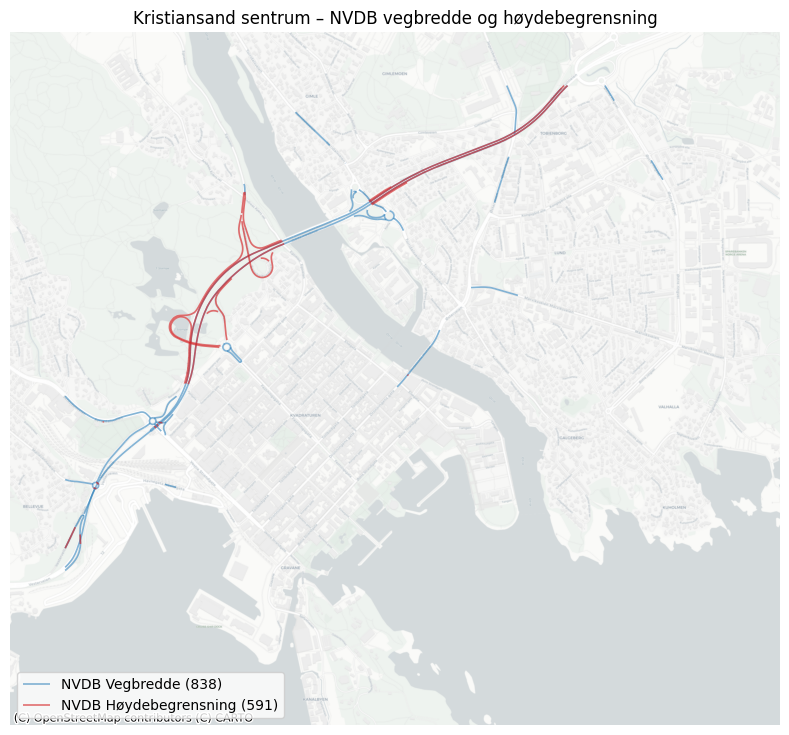

In [105]:
# Kart med bakgrunn som rendrer i notebooken (statisk bilde)
import sys
import subprocess
import os

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

# Installer contextily hvis det mangler (pip i samme kernel)
try:
    import contextily as ctx
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as ctx

# Sørg for at tile-nedlasting bruker en fungerende CA-bundle (hindrer "heng" i SSL på noen oppsett)
try:
    import certifi
    os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
    os.environ["SSL_CERT_FILE"] = certifi.where()
except Exception:
    pass

def _parse_bbox(bbox_str: str):
    xmin, ymin, xmax, ymax = [float(x) for x in bbox_str.split(",")]
    return xmin, ymin, xmax, ymax


# Bruk samme sentrum-bbox som i visualisering / fetch
xmin, ymin, xmax, ymax = _parse_bbox(BBOX_SENTRUM)
bbox_wgs84 = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:4326")

# Prosjiser til Web Mercator (EPSG:3857) for basemap tiles
bbox_3857 = bbox_wgs84.to_crs(epsg=3857)
width_3857 = width_gdf.to_crs(epsg=3857)
height_3857 = height_gdf.to_crs(epsg=3857)

minx, miny, maxx, maxy = bbox_3857.total_bounds
bbox_poly_3857 = bbox_3857.geometry.iloc[0]

# Klipp geometrier til utsnittet slik at bare det som er i kartet vises

def _clip_to_bbox(gdf: gpd.GeoDataFrame, bbox_poly):
    out = gdf.copy()
    out["geometry"] = out.geometry.intersection(bbox_poly)
    geom = out.geometry
    mask = (~geom.isna()) & (~geom.is_empty)
    out = out[mask]
    return out

width_view = _clip_to_bbox(width_3857, bbox_poly_3857)
height_view = _clip_to_bbox(height_3857, bbox_poly_3857)

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Bakgrunnskart
basemap_zoom = 16
crs_3857 = width_3857.crs.to_string()
try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        zoom=basemap_zoom,
        crs=crs_3857,
        reset_extent=False,
        zorder=0,
    )
except Exception as e:
    print("Klarte ikke å laste bakgrunnskart (tiles):", repr(e))

# Kun de to NVDB-lagene: 838 og 591
width_view.plot(
    ax=ax,
    color="#1f77b4",
    linewidth=1.2,
    alpha=0.55,
    label="NVDB Vegbredde (838)",
    zorder=5,
)
height_view.plot(
    ax=ax,
    color="#d62728",
    linewidth=1.2,
    alpha=0.65,
    label="NVDB Høydebegrensning (591)",
    zorder=6,
)

ax.set_title("Kristiansand sentrum – NVDB vegbredde og høydebegrensning")
ax.axis("off")
ax.legend(loc="lower left")
plt.show()

Flitering

Buffersone rundt broer

Smale segmenter (<= 3.2 m): 4
Lave segmenter (<= 4.2 m): 1
Overlap-hotspots: 0
Nærhets-hotspots (<= 120 m): 0


Smale segmenter (<= 3.2 m): 4
Lave segmenter (<= 4.2 m): 1
Overlap-hotspots: 0
Nærhets-hotspots (<= 120 m): 0


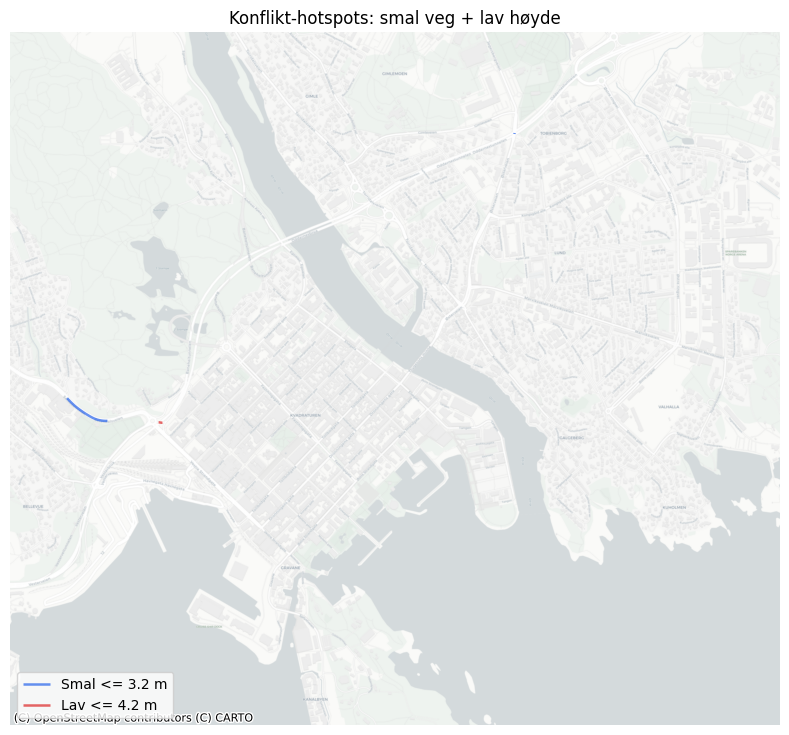

Aggregering Vei tetthet inforbi et område (komune)

Raster analyser